<a href="https://colab.research.google.com/github/NIVETHA-NS/GENARATIVE-AI-AND-LARGE-LANGUAGE-MODELS_LAB_2026/blob/main/GEN_AI_FROM_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U "datasets>=3.0.0" "huggingface_hub>=0.25.0" transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.27.0
    Uninstalling huggingface_hub-1.27.0:
      Successfully uninstalled huggingface_hub-1.27.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.15.0
    Uninstalling transformers-5.15.0:
      Successfully uninstalled transformer

In [1]:
import datasets
import huggingface_hub

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 5.0.1
huggingface_hub: 1.28.0


In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [3]:
small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

print(small_train)
print(small_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 500
})


In [4]:
!pip install -U datasets huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.


In [1]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [2]:
# Install required libraries
!pip install -U datasets transformers accelerate scikit-learn

# Import libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Load IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

# 2. Select a smaller dataset for faster training
small_train = dataset["train"].shuffle(seed=42).select(range(2000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

print("Training samples:", len(small_train))
print("Testing samples:", len(small_test))

# 3. Load pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 4. Tokenization
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = small_train.map(tokenize, batched=True)
test_ds = small_test.map(tokenize, batched=True)

# Remove original text column
train_ds = train_ds.remove_columns(["text"])
test_ds = test_ds.remove_columns(["text"])

# 5. Load pre-trained DistilBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# 6. Training arguments
args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    logging_steps=50,
    report_to="none"
)

# 7. Accuracy metric
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds)
    }

# 8. Create Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

# 9. Train the model
print("Starting training...")
trainer.train()

# 10. Evaluate the model
metrics = trainer.evaluate()

print("\nEvaluation metrics:")
print(metrics)

# 11. Save model and tokenizer
model.save_pretrained("./fine_tuned_distilbert_imdb")
tokenizer.save_pretrained("./fine_tuned_distilbert_imdb")

print("\nModel saved successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Training samples: 2000
Testing samples: 500


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
0.219011,0.627704,2,0.812000



Evaluation metrics:
{'eval_loss': 0.6277036666870117, 'eval_accuracy': 0.812}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved successfully!


In [3]:
!pip install -U transformers diffusers accelerate gtts sentencepiece

INFO: pip is looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 64.3 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.39.0
    Uninstalling diffusers-0.39.0:
      Successfully uninstalled diffusers-0.39.0


In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from diffusers import StableDiffusionPipeline
from gtts import gTTS
import torch

topic = "The benefits of renewable energy"

# --------------------------------------------------
# 1. TEXT GENERATION
# --------------------------------------------------

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
text_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

text_prompt = f"Write a short, engaging paragraph about: {topic}"

inputs = tokenizer(
    text_prompt,
    return_tensors="pt"
)

outputs = text_model.generate(
    **inputs,
    max_new_tokens=80
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("Generated Text:\n")
print(generated_text)


# --------------------------------------------------
# 2. IMAGE GENERATION
# --------------------------------------------------

image_prompt = f"An illustration representing {topic}, digital art"

sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

sd_pipe = sd_pipe.to("cuda")

image = sd_pipe(
    image_prompt,
    num_inference_steps=25
).images[0]

image.save("content_image.png")

print("\nImage saved as content_image.png")


# --------------------------------------------------
# 3. AUDIO GENERATION
# --------------------------------------------------

tts = gTTS(
    text=generated_text,
    lang="en"
)

tts.save("content_audio.mp3")

print("Audio saved as content_audio.mp3")

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]


Image saved as content_image.png
Audio saved as content_audio.mp3


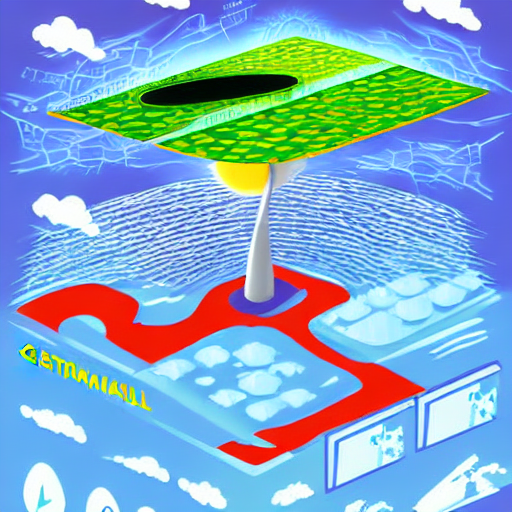

In [8]:
from IPython.display import display
from PIL import Image

image = Image.open("content_image.png")
display(image)

In [10]:
from IPython.display import Audio

Audio("content_audio.mp3")

In [13]:
!pip install -U transformers gradio evaluate rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 2.6.0
    Uninstalling gradio_client-2.6.0:
      Successfully uninstalled gradio_client-2.6.0
  Attempting uninstall: gradio
    Found existing installation: gradio 6.24.0
    Uninstalling gradio-6.24.0:
      Successfully uninstalled gradio-6.24.0


In [1]:
import transformers
print(transformers.__version__)

5.15.1


In [3]:
!pip install -q transformers gradio evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [10]:
!pip uninstall -y transformers tokenizers huggingface-hub
!pip install -q transformers==4.46.3 tokenizers==0.20.3 huggingface-hub==0.26.2
!pip install -q evaluate rouge_score sentencepiece

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3
Found existing installation: tokenizers 0.20.3
Uninstalling tokenizers-0.20.3:
  Successfully uninstalled tokenizers-0.20.3
Found existing installation: huggingface_hub 1.28.0
Uninstalling huggingface_hub-1.28.0:
  Successfully uninstalled huggingface_hub-1.28.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 26.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.26.2 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.2 which is incompatible.


In [1]:
import transformers
import huggingface_hub
import tokenizers
import gradio

print("Transformers:", transformers.__version__)
print("HuggingFace Hub:", huggingface_hub.__version__)
print("Tokenizers:", tokenizers.__version__)
print("Gradio:", gradio.__version__)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Transformers: 4.46.3
HuggingFace Hub: 0.26.2
Tokenizers: 0.20.3
Gradio: 6.24.0


In [2]:
from transformers import pipeline

print("Loading model...")

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

print("Model loaded successfully!")

Loading model...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Model loaded successfully!


In [4]:
import gradio as gr
from transformers import pipeline
import evaluate

# ---------- 1. Load Summarization Model ----------

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)


# ---------- 2. Summarization Function ----------

def summarize_text(input_text):
    if not input_text.strip():
        return "Please enter some text."

    result = summarizer(
        input_text,
        max_length=100,
        min_length=30,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True,
        do_sample=False
    )

    return result[0]["summary_text"]


# ---------- 3. Create Gradio Interface ----------

demo = gr.Interface(
    fn=summarize_text,
    inputs=gr.Textbox(
        lines=10,
        label="Enter text to summarize"
    ),
    outputs=gr.Textbox(
        label="Generated Summary"
    ),
    title="GenAI Text Summarizer",
    description="A cloud-deployable Generative AI summarization app built with Gradio."
)


# ---------- 4. Evaluate Generated Output ----------

rouge = evaluate.load("rouge")

generated_summaries = [
    "AI models generate new content such as text and images."
]

reference_summaries = [
    "Generative AI models are capable of producing new content including text and images."
]

scores = rouge.compute(
    predictions=generated_summaries,
    references=reference_summaries
)

print("ROUGE Evaluation Scores:", scores)


# ---------- 5. Launch Gradio App ----------

demo.launch(share=True)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


ROUGE Evaluation Scores: {'rouge1': np.float64(0.608695652173913), 'rouge2': np.float64(0.380952380952381), 'rougeL': np.float64(0.608695652173913), 'rougeLsum': np.float64(0.608695652173913)}
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7842db04f6b106f897.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
